In [1]:
import sys
!{sys.executable} -m ensurepip --default-pip


Looking in links: /tmp/tmpaqo_3n45


In [2]:
%pip install accelerate matplotlib seaborn bitsandbytes pandas transformers accelerate tqdm datasets

Looking in indexes: https://mcache-dsm.massedcompute.com/simple, https://pypi.org/simple

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from datasets import load_dataset
from transformers import AutoProcessor, DiffusionGemmaForBlockDiffusion
import torch
# ==========================================
# 1. DATASET / PROMPT LOADING
# ==========================================
class DataLoader:
    """
    Handles fetching and preparing text data to feed into the models.
    Relies on the Hugging Face `datasets` library.
    """
    @staticmethod
    def load_sample_text(dataset_path="Salesforce/wikitext", name="wikitext-103-raw-v1", split="validation", min_length=50, num_paragraphs=2):
        """
        Loads a dataset from the Hugging Face Hub, filters out short/empty lines, 
        and joins several paragraphs together to create a single long input prompt.

        WHAT NEEDS TO BE CUSTOMIZED (For your own data):
        ------------------------------------------------
        - `dataset_path` (str): The Hugging Face repo ID (e.g., "Salesforce/wikitext", "imdb").
        - `name` (str): The specific subset configuration of the dataset. If the dataset 
          doesn't have subsets, you can pass `name=None`.
        - `split` (str): Which split to use (usually "train", "test", or "validation").
        - `min_length` (int): Ignores text snippets with fewer characters than this (removes noise).
        - `num_paragraphs` (int): How many valid text rows to combine into your final prompt.
        """
        print(f"Loading dataset: {dataset_path} ({split} split)...")
        dataset = load_dataset(dataset_path, name, split=split)
        
        # Filter out empty strings or very short titles/headers
        texts = [text for text in dataset['text'] if len(text.strip()) > min_length]
        
        # Combine the requested number of paragraphs into one block of text
        return " ".join(texts[:num_paragraphs])

/home/shadeform/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1" # Forces standard downloads

import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import AutoProcessor, DiffusionGemmaForBlockDiffusion, BitsAndBytesConfig

# ==========================================
# 1. ENTROPY COMPUTATION ENGINE (General)
# ==========================================
class EntropyEngine:
    @staticmethod
    def compute_from_logits(logits):
        """Computes entropy, max confidence, and top token IDs from raw logits."""
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        
        entropy = -torch.sum(probs * log_probs, dim=-1)
        top_confidence, top_token_ids = torch.max(probs, dim=-1)
        
        return entropy, top_confidence, top_token_ids

# ==========================================
# 2. DIFFUSION EXTRACTION PIPELINE (Hook-Based)
# ==========================================
class DiffusionHookExtractor:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.device = model.device

    def _locate_modules(self):
        """
        [ARCHITECTURE-SPECIFIC AREA]: 
        Different models name their output heads and MoE routers differently.
        """
        router_module = None
        lm_head_module = None
        
        # 1. Find the MoE Router (If applicable)
        # Note: If you use a non-MoE model (like Dhara-70m), this will stay None.
        for name, module in self.model.named_modules():
            if name.endswith('.gate') or name.endswith('.router'):
                router_module = module
                
        # 2. Find the Final Output Head (Language Modeling Head)
        lm_head_module = self.model.get_output_embeddings()
        if lm_head_module is None and hasattr(self.model, 'lm_head'):
            lm_head_module = self.model.lm_head
            
        if lm_head_module is None:
            raise ValueError("CRITICAL ERROR: Could not locate the LM head.")
            
        return router_module, lm_head_module

    def run_analysis(self, formatted_prompt, canvas_size=256, arch_name="Generic-Diffusion"):
        inputs = self.tokenizer(formatted_prompt, return_tensors="pt").to(self.device)
        
        # Setup Storage for Sensors
        captured_data = {'prediction_logits': [], 'router_logits': []}
        
        # [ARCHITECTURE-SPECIFIC AREA]: Hook Output Formatting
        # Some models return tuples, some return raw tensors, some return dictionaries.
        def router_hook(module, args, output):
            logits = output[0] if isinstance(output, tuple) else output
            captured_data['router_logits'].append(logits.clone().detach().cpu())
            
        def lm_head_hook(module, args, output):
            logits = output[0] if isinstance(output, tuple) else output
            captured_data['prediction_logits'].append(logits.clone().detach().cpu())

        # Attach Hooks
        router_module, lm_head_module = self._locate_modules()
        
        hooks = []
        if router_module:
            hooks.append(router_module.register_forward_hook(router_hook))
        hooks.append(lm_head_module.register_forward_hook(lm_head_hook))
        
        print(f"Running native generation for {arch_name}... (Passive monitoring active)")
        try:
            with torch.no_grad():
                # [ARCHITECTURE-SPECIFIC AREA]: Generation kwargs
                # `max_new_tokens` works for Gemma. Other models might require specific
                # diffusion step kwargs or canvas size params inside `.generate()`
                _ = self.model.generate(**inputs, max_new_tokens=canvas_size)
        finally:
            # CRITICAL: Always remove hooks to prevent VRAM leaks
            for h in hooks:
                h.remove()
                
        return self._process_captured_data(captured_data, canvas_size, arch_name)

    def _process_captured_data(self, captured_data, canvas_size, arch_name):
        print(f"Generation complete! Captured {len(captured_data['prediction_logits'])} total forward passes.")
        
        # --- THE PREFILL FIX ---
        # Discard the initial prompt evaluation pass so we only analyze the diffusion steps
        captured_data['prediction_logits'].pop(0)
        
        # Define has_router based on whether our hook actually caught any MoE data
        has_router = len(captured_data['router_logits']) > 0
        if has_router:
            captured_data['router_logits'].pop(0)
        # -----------------------

        records = []
        num_steps = len(captured_data['prediction_logits'])
        
        prev_step_predictions = {}
        prev_step_entropy = {}

        for step_idx in tqdm(range(num_steps), desc="Processing Captured Steps"):
            p_logits = captured_data['prediction_logits'][step_idx]
            
            # Isolate the canvas (the tokens at the end of the sequence)
            canvas_p_logits = p_logits[0, -canvas_size:, :]
            
            p_entropy, p_conf, p_ids = EntropyEngine.compute_from_logits(canvas_p_logits)
            
            # Handle Router Logits if they exist
            r_entropy_list = [0.0] * canvas_size
            if has_router:
                r_logits = captured_data['router_logits'][step_idx]
                if r_logits.dim() == 2:
                    r_logits = r_logits.view(p_logits.shape[0], p_logits.shape[1], -1)
                canvas_r_logits = r_logits[0, -canvas_size:, :]
                r_entropy, _, _ = EntropyEngine.compute_from_logits(canvas_r_logits)
                r_entropy_list = r_entropy.tolist()
            
            p_ids_list = p_ids.tolist()
            p_entropy_list = p_entropy.tolist()
            p_conf_list = p_conf.tolist()
            
            for i in range(len(p_ids_list)):
                predicted_token_id = p_ids_list[i]
                current_entropy = p_entropy_list[i]
                
                if step_idx > 0:
                    entropy_drop = prev_step_entropy[i] - current_entropy
                    token_changed = (predicted_token_id != prev_step_predictions[i])
                else:
                    entropy_drop = 0.0
                    token_changed = False
                    
                prev_step_entropy[i] = current_entropy
                prev_step_predictions[i] = predicted_token_id
                
                records.append({
                    "architecture": arch_name,
                    "denoising_step": step_idx,
                    "canvas_position": i,
                    "prediction_entropy": current_entropy,
                    "router_entropy": r_entropy_list[i],
                    "entropy_drop": entropy_drop,
                    "top_confidence": p_conf_list[i],
                    "predicted_token": self.tokenizer.decode([predicted_token_id]),
                    "token_changed_from_prev_step": token_changed
                })
                
        return pd.DataFrame(records)

class DiffusionDataAnalyzer:
    @staticmethod
    def _apply_theme():
        """Helper method to apply the professional styling to all charts."""
        sns.set_theme(style="whitegrid", context="talk")

    @staticmethod
    def plot_token_trajectory(df, target_positions, save_path="trajectory.png"):
        """Plots the entropy descent of specific canvas positions over time."""
        DiffusionDataAnalyzer._apply_theme()
        plt.figure(figsize=(10, 5))
        for pos in target_positions:
            pos_data = df[df['canvas_position'] == pos]
            plt.plot(pos_data['denoising_step'], pos_data['prediction_entropy'], label=f"Position {pos}")
            
        plt.title("Entropy Denoising Trajectory Across Steps", pad=15)
        plt.xlabel("Denoising Step")
        plt.ylabel("Prediction Entropy")
        plt.legend(title="Canvas Position")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Trajectory plot saved to {save_path}")

    @staticmethod
    def plot_final_entropy_distribution(df, final_step, save_path="final_entropy_dist.png"):
        """Plots the distribution of entropy at the final denoising step."""
        DiffusionDataAnalyzer._apply_theme()
        df_final = df[df['denoising_step'] == final_step]
        
        plt.figure(figsize=(8, 6))
        
        # Check if the 'is_correct' column exists (used when evaluating against WikiText datasets)
        if 'is_correct' in df.columns:
            custom_palette = {True: "#2ecc71", False: "#e74c3c", "True": "#2ecc71", "False": "#e74c3c"}
            
            sns.boxplot(
                data=df_final, 
                x='is_correct', 
                y='prediction_entropy', 
                hue='is_correct',        
                palette=custom_palette,
                showfliers=False,
                legend=False             
            )
            
            plt.xticks(ticks=[0, 1], labels=["Incorrect", "Correct"])
            plt.xlabel("Model Prediction")
        else:
            sns.histplot(df_final['prediction_entropy'], kde=True, color="#3498db")
            plt.xlabel("Prediction Entropy")
            
        plt.title(f"Final Entropy Distribution (Step {final_step})", pad=15)
        plt.ylabel("Prediction Entropy")
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Distribution plot saved to {save_path}")
    
    @staticmethod
    def plot_denoising_heatmap(df, save_path="wikitext_1_heatmap.png"):
        """Generates a heatmap of token uncertainty over time."""
        DiffusionDataAnalyzer._apply_theme()
        print("Generating Heatmap...")
        plt.figure(figsize=(14, 8))
        
        heatmap_data = df.pivot(index='canvas_position', columns='denoising_step', values='prediction_entropy')
        sns.heatmap(heatmap_data, cmap="viridis", cbar_kws={'label': 'Prediction Entropy'})
        
        plt.title("Denoising Heatmap: Token Uncertainty Over Time", pad=15)
        plt.xlabel("Diffusion Denoising Step")
        plt.ylabel("Token Position in Sequence")
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Heatmap saved to {save_path}")

    @staticmethod
    def plot_aha_moment_histogram(df, save_path="wikitext_2_aha_moment.png"):
        """Plots a histogram of when tokens experience their largest entropy drop."""
        DiffusionDataAnalyzer._apply_theme()
        print("Generating 'Aha!' Moment Histogram...")
        plt.figure(figsize=(10, 6))

        max_drop_idx = df.groupby('canvas_position')['entropy_drop'].idxmax()
        max_drop_steps = df.loc[max_drop_idx]
        max_step = df['denoising_step'].max()

        sns.histplot(data=max_drop_steps, x='denoising_step', bins=max_step+1, color="#e74c3c", kde=True)
        plt.title("The 'Aha!' Moment: When Tokens Experience Max Information Gain", pad=15)
        plt.xlabel("Denoising Step")
        plt.ylabel("Number of Tokens")
        plt.xlim(0, max_step)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"'Aha!' moment histogram saved to {save_path}")

    @staticmethod
    def plot_router_correlation(df, save_path="wikitext_3_scatter.png"):
        """Scatters MoE Router entropy vs Prediction entropy."""
        DiffusionDataAnalyzer._apply_theme()
        print("Generating Correlation Scatter Plot...")
        plt.figure(figsize=(10, 6))

        sns.scatterplot(data=df, x='prediction_entropy', y='router_entropy', alpha=0.15, color="#3498db", edgecolor=None)
        plt.title("Correlation: MoE Router vs. Token Prediction Uncertainty", pad=15)
        plt.xlabel("Prediction Entropy (Word Uncertainty)")
        plt.ylabel("MoE Router Entropy (Expert Uncertainty)")
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Correlation scatter plot saved to {save_path}")

    @staticmethod
    def plot_cumulative_freeze(df, save_path="wikitext_4_cumulative_freeze.png"):
        """Plots the cumulative distribution of when tokens stop changing (lock-in)."""
        DiffusionDataAnalyzer._apply_theme()
        print("Generating Cumulative Freeze Curve...")
        plt.figure(figsize=(10, 6))

        last_change_steps = df[df['token_changed_from_prev_step'] == True].groupby('canvas_position')['denoising_step'].max()
        
        # Dynamically determine canvas size based on the dataset
        canvas_size = df['canvas_position'].nunique()
        max_step = df['denoising_step'].max()
        
        all_freeze_steps = pd.Series(index=range(canvas_size), dtype=float).fillna(0)
        all_freeze_steps.update(last_change_steps)

        sns.ecdfplot(data=all_freeze_steps, color="#9b59b6", linewidth=4)
        plt.title("Token 'Freeze' Point: Cumulative Canvas Stability", pad=15)
        plt.xlabel("Denoising Step")
        plt.ylabel("Percentage of Stable Tokens")
        plt.xlim(0, max_step)
        
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Cumulative freeze curve saved to {save_path}")

Loading Processor and Model from Hugging Face...


Loading weights: 100%|██████████| 1047/1047 [00:04<00:00, 215.24it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


Loading dataset: Salesforce/wikitext (test split)...

Fetched custom text for prompt: ' Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role...'

Running native generation for DiffusionGemma-26B-MoE... (Passive monitoring active)
Generation complete! Captured 18 total forward passes.


Processing Captured Steps: 100%|██████████| 17/17 [00:01<00:00, 11.29it/s]



Extraction complete! Dataset shape: (4352, 9) | Saved to diffusion_gemma_entropy_results.csv

Generating Analytics Plots...
Generating Heatmap...


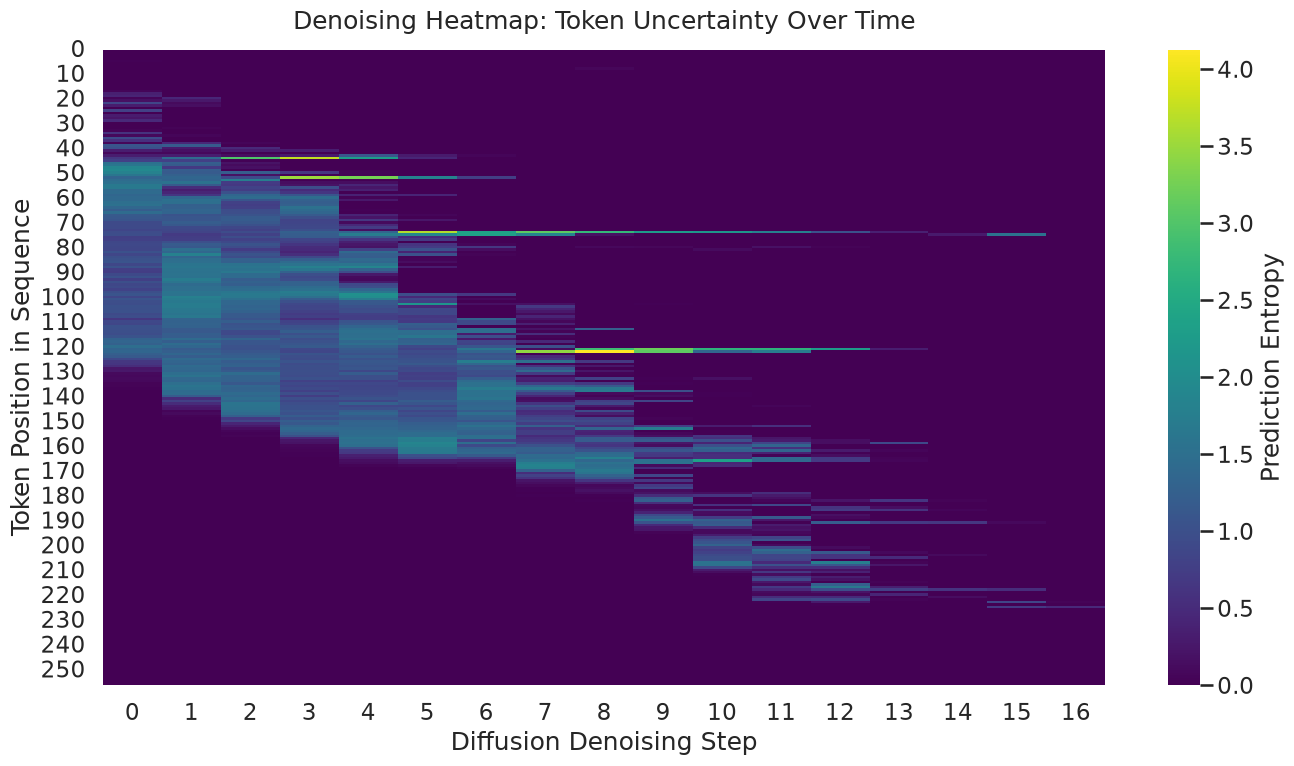

Heatmap saved to wikitext_1_heatmap.png
Generating 'Aha!' Moment Histogram...


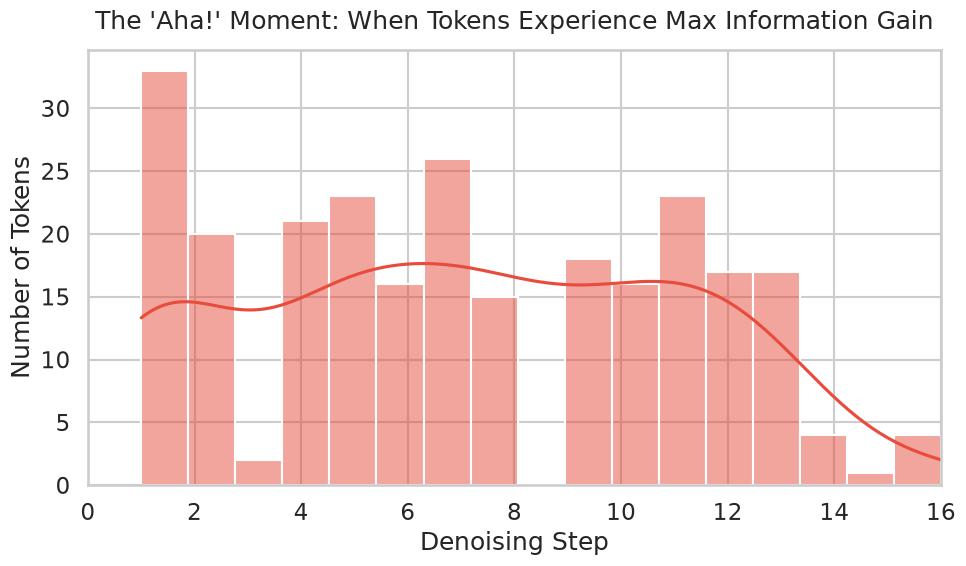

'Aha!' moment histogram saved to wikitext_2_aha_moment.png
Generating Correlation Scatter Plot...


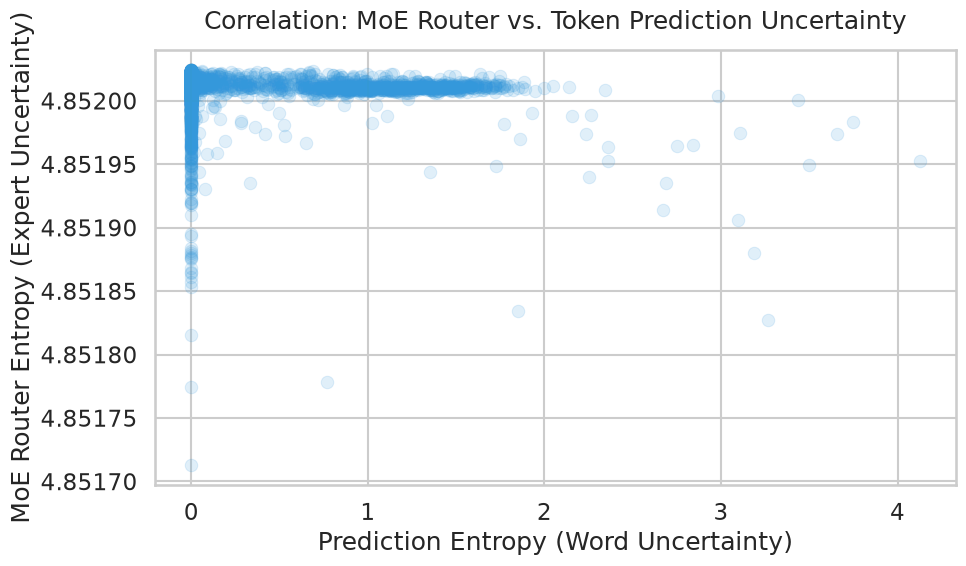

Correlation scatter plot saved to wikitext_3_scatter.png
Generating Cumulative Freeze Curve...


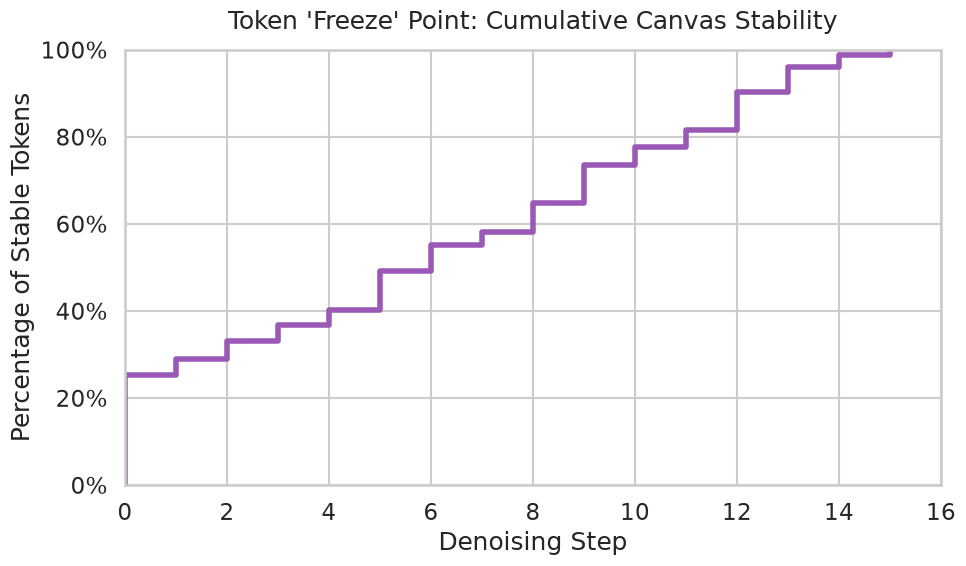

Cumulative freeze curve saved to wikitext_4_cumulative_freeze.png


In [5]:
import gc
import torch

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Clean up Jupyter Memory (Prevents OOM crashes on the A100)
    if 'model' in locals(): del model
    if 'processor' in locals(): del processor
    gc.collect()
    torch.cuda.empty_cache()

    print("Loading Processor and Model from Hugging Face...")
    model_id = "google/diffusiongemma-26B-A4B-it"
    
    # Load Processor
    processor = AutoProcessor.from_pretrained(model_id)
    
    # Load Model 
    # (Changed device_map to "auto" for safer VRAM allocation)
    model = DiffusionGemmaForBlockDiffusion.from_pretrained(
        model_id, 
        device_map="auto", 
        torch_dtype=torch.bfloat16
    )

    # ---------------------------------------------------------
    # CUSTOMIZE YOUR INPUT HERE
    # ---------------------------------------------------------
    # Fetch custom text (e.g., WikiText)
    custom_text = DataLoader.load_sample_text(
        dataset_path="Salesforce/wikitext", 
        name="wikitext-103-raw-v1", 
        split="test", 
        min_length=100, 
        num_paragraphs=1 
    )
    
    print(f"\nFetched custom text for prompt: '{custom_text[:100]}...'\n")

    # Format the dataset text into an instruction prompt
    messages = [
        {"role": "user", "content": [{"type": "text", "text": f"Continue this text: {custom_text}"}]}
    ]
    
    formatted_prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False
    )

    # ---------------------------------------------------------
    # INITIALIZE THE NEW HOOK EXTRACTOR
    # ---------------------------------------------------------
    extractor = DiffusionHookExtractor(model, processor.tokenizer)
    
    # Run the extraction loop
    # Note: diffusion_steps is removed! The hooks automatically capture 
    # whatever steps the model's native scheduler decides to run.
    df_results = extractor.run_analysis(
        formatted_prompt=formatted_prompt, 
        canvas_size=256, 
        arch_name="DiffusionGemma-26B-MoE"
    )
    
    # Save raw data
    output_csv = "diffusion_gemma_entropy_results.csv"
    df_results.to_csv(output_csv, index=False)
    print(f"\nExtraction complete! Dataset shape: {df_results.shape} | Saved to {output_csv}")
    
    # ---------------------------------------------------------
    # RUN ADVANCED ANALYTICS (Using the updated class)
    # ---------------------------------------------------------
    print("\nGenerating Analytics Plots...")
    
    DiffusionDataAnalyzer.plot_denoising_heatmap(df_results)
    DiffusionDataAnalyzer.plot_aha_moment_histogram(df_results)
    DiffusionDataAnalyzer.plot_router_correlation(df_results)
    DiffusionDataAnalyzer.plot_cumulative_freeze(df_results)